# Loading modules/functions

In [1]:
#
# Jupyter python notebook to estimate ARGO Oxygen Correction.
# DOXY_ADJUSTED is corrected via the correction of the partial pressure PPOX as in 'Bittig and al (2018)'
# https://dx.doi.org/10.3389/fmars.2017.00429

#instruction to be able to zoom on matplotlib figure
%matplotlib widget 

# Path to LOCODOX python
import sys
sys.path.insert(0,'/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/source')

# Import python module
import os
import argopy
import xarray as xr
import glob
import numpy as np
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)
import matplotlib.pyplot as plt
import matplotlib
#matplotlib.rcParams["figure.dpi"] = 100 
#matplotlib.use('module://ipympl.backend_nbagg')
from scipy.optimize import curve_fit
import gsw
from datetime import date, datetime
import copy
import pwlf
import shutil
import time
#from wrangling import interp_climatology


# Import module developped for LOCODOX
from m_argo_data import open_argo_multi_profile_file, get_argo_launch_date, get_argo_optode_height, get_argo_data_for_WOA
from m_argo_data import get_argo_data_for_NCEP
from m_WOA_data import open_WOA_file, interp_WOA_on_ARGO
from m_NCEP_data import open_NCEP_file, interp_NCEP_on_ARGO, calcul_NCEP_PPOX
from m_NCEP_data import download_NCEP_if_needed
from m_users_fonctions import interp_pres_grid,O2stoO2p, O2ctoO2p, O2ptoO2c, O2ctoO2s,umolkg_to_umolL, diff_time_in_days, copy_attr, write_param_results, interp_climatology_float
from m_users_fonctions import cherche_info_ctd_ref
from m_model_curve_fit import model_Gain, model_Gain_Derive, model_Gain_CarryOver, model_Gain_Derive_CarryOver, model_Gain_pres, model_AXplusB
from m_users_plot import plot_WMO_position, plot_DOXY_QC, plot_QC_cycle, plot_DOXY_cycle, plot_ppox_Inair_Inwater_Ncep, plot_cmp_corr_NCEP, plot_cmp_corr_WOA
from m_users_plot import plot_cmp_ARGO_CTD, plot_cmp_corr_oxy_woa, plot_Theta_S, plot_CTD_Argo_Pos, plot_cmp_corr_NCEP_with_error, plot_cmp_corr_WOA_with_error, plot_ref_div_argo
from m_users_plot import plot_cmp_correction_with_WOA
from m_read_write_netcdf import corr_file, corr_file_with_ppox

/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/source/m_read_write_netcdf.py:7: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


# User initialization

In [2]:
#####################
# Initialization.
###################

# ARGO Directory : contains 1 subdirectory by float.
# In the Argo float directory, you can find the Rtraj/Sprof/meta Netcdf Files and the 'profiles' subdirectory
# with the BR/BR and R/D files
# WMO Float (string format) to be corrected / Cycles to be used
#################################################################
# Argo directory
#rep_data_argo = '/Volumes/argo/gdac/dac/coriolis/'
fic_txt = '/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/BDD_TR/bdd_REF_ARGO.txt'
fic_mat = '/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/BDD_TR/bddo2ref_all_2025.mat'
rep_data_argo = '/Volumes/argo/gdac/dac/coriolis/'
# Argo float
num_float = '6902807' #Flotteur PIRATA mort qui a duré + 7 ans

# CTD comparison to estimate a supplement gain.
##################################################
# cmp_ctd = 1 : we used CTD, 0 otherwise
cmp_ctd = 0
fic_txt = '/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/BDD_TR/bdd_REF_ARGO.txt'
fic_mat = '/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/BDD_TR/bddo2ref_all_2025.mat'
if cmp_ctd==1:
    num_ctd,num_cycle,cruise_name, ds_cruise = cherche_info_ctd_ref(fic_txt,fic_mat,num_float)
else:
    num_ctd = []
    num_cycle = []


# Cycle to use to estimate the correction
first_cycle_to_use = 1
last_cycle_to_use = 400

# Piecewise or not
test_piece = 0
# Compute automatically NCEP breakpoint or force it
compute_NCEP_breakpoint=0
if test_piece==1:
    nb_segment_WOA = 2
# Compute automatically NCEP breakpoint or force it
    if compute_NCEP_breakpoint==1:
        breakpoint_NCEP_user = 150 #delta_T_NCEP[7] # To be 
    else:
        nb_segment_NCEP=2

# Results Directory.
# A subdirectory named numfloat_date will be created for each run in the result directory.
# The ASCII file will be created in it.
# The B corrected files and plots will be created in a subdirectory (nc and plot subdirectory)
###################################################
rep_fic_res = '/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/fic_res_janvier2026'
now = datetime.now()
date_str = now.strftime("%Y%m%d%H%M")
rep_fic_res_final = os.path.join(rep_fic_res,num_float + '_' + date_str)
rep_fic_fig = os.path.join(rep_fic_res_final,'plot') # Plot
rep_fic_nc = os.path.join(rep_fic_res_final,'nc') # NetCDF
os.makedirs(rep_fic_res_final, exist_ok=True)
os.makedirs(rep_fic_fig, exist_ok=True)
os.makedirs(rep_fic_nc, exist_ok=True)
# ASCII file name
racine_res = 'locodox_res_'
fic_res_ASCII = os.path.join(rep_fic_res_final,racine_res + num_float)

# Default pressure coefficient used in ARGO
# sensor_aanderaa = 1 if aanderaa sensor, 0 if rinko sensor
sensor_aanderaa = 1
if sensor_aanderaa == 1:
    racine_res = racine_res + 'aanderaa_' 
    pcoef2 = 0.00022
    pcoef3 = 0.0419
else:
    racine_res = racine_res + 'rinko_' 
    pcoef2 = 0
    pcoef3 = 0.04

# Relative error to be written in the BD files
percent_relative_error = 2.0

# Which plot ?
###############
# info_plot = 1 : all plots
# info_plot = 0 : not all plots are created.
info_plot = 1 

# Which ARGO variables (PRES/PSAL/TEMP) to be used to estimate correction.
#################################################
# which_var = 1 : RAW Data
# which_var = 2 : Adjusted Data
# which_var = 3 : Adjusted Data if available, otherwise Raw Data
which_var = 3
if which_var==1:
    str_chaine = ''
else:
    str_chaine='_ADJUSTED'

# Which QC used for pressure, temperature, salinity and oxygen.
# In Sprof, we got interpolated data (flag=8)
pres_qc = [1,2,8]
temp_qc = [1,2,8]
sal_qc = [1,2,8]
doxy_qc = [1,2,3,8]

# ARGO InAir code
code_inair = [699,711,799]
# Argo InWater code
code_inwater = [690,710]
# Min and max pressure to extract the salinity for inwater data (because for inwater data, the pump is off.
# So, we decided to take the salinity from the profile (with the pump on).
min_pres = 0
max_pres = 10

# CTD comparison to estimate a supplement gain.
##################################################
# cmp_ctd = 1 : we used CTD, 0 otherwise
cmp_ctd = 1



# Pressure effect 
###################
# Pressure for pressure effect estimation. We use pressure > pressure_threshold
pressure_threshold = 1000  

# Bathymetry plot
# Bathymetry file
fic_bathy = '/Users/chemon/ARGO_NEW/LOCODOX/DATA/LOCODOX_EXTERNAL_DATA/TOPOGRAPHY/ETOPO2v2c_f4.nc'
#  Dataset associated
ds_bathy = xr.open_dataset(fic_bathy)
# extension for Position plot
extend_lon_lat = 1
# Depth for bathymetry contouring
depths = np.arange(-7000,500,500)

# WOA correction
##################
# fic_woa : WOA file
# Tis file contains the WOA variables (doxywoa,Psatwoa/density/preswoa/PSAL_WOA/TEMP_WOA).
# Ex : doxywoa(time,Depth,lat,lon) with time=12,lat=180,lon=360,Depth=102 : contains the monthly average of doxy
# This file is created by an internal LOPS routine. !!! To change !!!
#
# WOA file
fic_WOA = '/Users/chemon/ARGO_NEW/LOCODOX/DATA/LOCODOX_EXTERNAL_DATA/WOA/WOA2018_DECAV_monthly_5500_1deg.nc'
# Min and max pressure used to estimate WOA correction. 
min_pres_interp = 0
max_pres_interp = 25

# NCEP Correction
######################
# NCEP directory : where the NCEP slp/air.sig995/rhum.sig995 can be found or downloaded if needed
rep_NCEP_data= '/Users/chemon/ARGO_NEW/NEW_LOCODOX/NCEP_DATA/'
# NCEP ftp server
ftp_server = 'ftp.cdc.noaa.gov'
# Ncep ftp directory
rep_ftp = 'Datasets/ncep.reanalysis/surface'
# NCEP variables needed.
ncep_variables = ['slp','air.sig995','rhum.sig995']

# ARGO reading and selection
## We use the NetCDF Argo file 
- meta file
- Sprof file
- Rtraj file

In [3]:
# Read ARGO files 
ds_argo_meta = open_argo_multi_profile_file(num_float,rep_data_argo,'meta')
ds_argo_Sprof = open_argo_multi_profile_file(num_float,rep_data_argo,'Sprof')
ds_argo_Rtraj = open_argo_multi_profile_file(num_float,rep_data_argo,'Rtraj')

/Volumes/argo/gdac/dac/coriolis/6902807/6902807_meta.nc
/Volumes/argo/gdac/dac/coriolis/6902807/6902807_Sprof.nc
/Volumes/argo/gdac/dac/coriolis/6902807/6902807_Rtraj.nc


/Users/chemon/miniforge3/envs/pydox_conda_forge/lib/python3.10/site-packages/argopy/xarray.py:2014: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filename_or_obj, decode_cf=1, use_cftime=0, mask_and_scale=1)


In [4]:
# Launch data
launch_date = get_argo_launch_date(ds_argo_meta)
print(launch_date)
optode_height = get_argo_optode_height(ds_argo_meta)
print(optode_height)
# Delta time from launch date
delta_T_Sprof = diff_time_in_days(ds_argo_Sprof['JULD'],launch_date)

2017-07-24T20:50:00.000000000
-0.291


In [5]:
# Select the cycles to be used
ds_argo_Sprof = ds_argo_Sprof.where((ds_argo_Sprof['CYCLE_NUMBER']>=first_cycle_to_use) & (ds_argo_Sprof['CYCLE_NUMBER']<=last_cycle_to_use),drop=True)
ds_argo_Rtraj = ds_argo_Rtraj.where( (ds_argo_Rtraj['CYCLE_NUMBER']>=first_cycle_to_use) & (ds_argo_Rtraj['CYCLE_NUMBER']<=last_cycle_to_use),drop=True)
ds_argo_Sprof['PLATFORM_NUMBER'] = ds_argo_Sprof['PLATFORM_NUMBER'].astype(int) # The where transform the nan from int to float ...

In [6]:
# Check ds_argo_Sprof
ds_argo_Sprof

<xarray.Dataset> Size: 68MB
Dimensions:                       (N_PROF: 272, N_PARAM: 4, N_CALIB: 2,
                                   N_LEVELS: 2012)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/58)
    DATA_TYPE                     (N_PROF) object 2kB 'Argo synthetic profile...
    FORMAT_VERSION                (N_PROF) object 2kB '1.0 ' '1.0 ' ... '1.0 '
    HANDBOOK_VERSION              (N_PROF) object 2kB '1.2 ' '1.2 ' ... '1.2 '
    REFERENCE_DATE_TIME           (N_PROF) datetime64[ns] 2kB 1950-01-01 ... ...
    DATE_CREATION                 (N_PROF) datetime64[ns] 2kB 2024-12-05T12:1...
    DATE_UPDATE                   (N_PROF) datetime64[ns] 2kB 2024-12-05T12:1...
    ...                            ...
    DOXY                          (N_PROF, N_LEVELS) float32 2MB 271.0 ... nan
    DOXY_QC                       (N_PROF, N_LEVELS) float64 4MB 4.0 0.0 ... 0.0
    DOXY_dPRES                    (N_PROF, N_LEVELS) float32 2MB 0.0 nan ... nan
    DOXY_ADJUSTED                 (N_PROF, N_LEVELS) float32 2MB nan nan ... nan
    DOXY_ADJUSTED_QC              (N_PROF, N_LEVELS) float64 4MB 4.0 0.0 ... 0.0
    DOXY_ADJUSTED_ERROR           (N_PROF, N_LEVELS) float32 2MB nan nan ... nan
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-05T12:15:43Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

# Plots

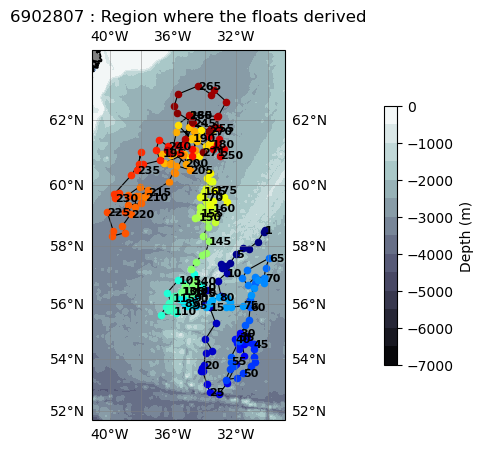

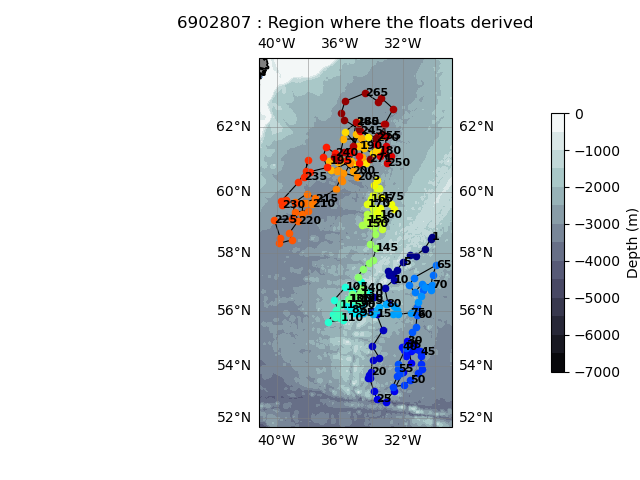

In [7]:
# Maps plotting
if info_plot==1:
    ds_bathy = xr.open_dataset(fic_bathy)
    depths = np.arange(-7000,500,500)
    fig = plot_WMO_position(ds_argo_Sprof, ds_bathy, depths,extend_lon_lat)
    #fig.canvas.draw_idle()  
    fig.savefig(os.path.join(rep_fic_fig,num_float +'_pos.png'))
    display(fig)

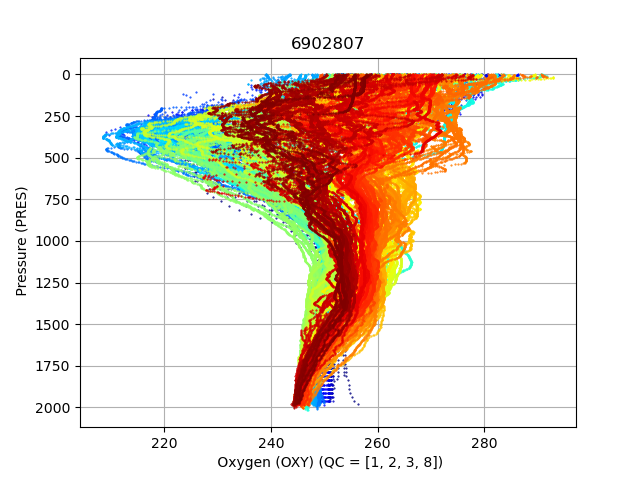

In [8]:
# DOXY RAW DATA
fig=plot_DOXY_cycle(ds_argo_Sprof,qc_keep=[1,2,3,8])
plt.show()
#fig.canvas.draw_idle()  

In [9]:
fig.savefig(os.path.join(rep_fic_fig,num_float +'_doxy_cycle.png'))

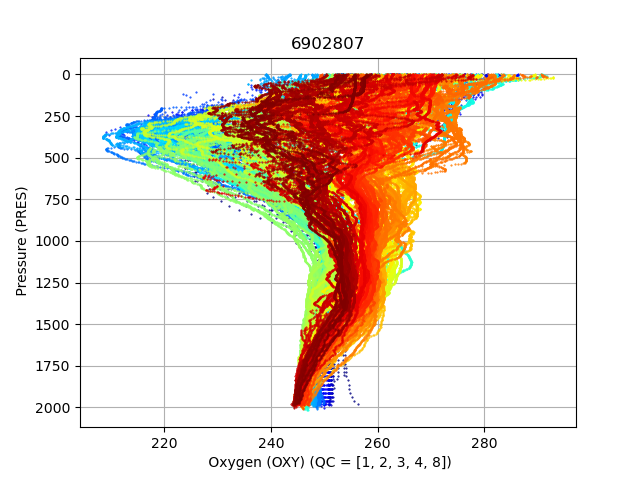

In [10]:
fig=plot_DOXY_cycle(ds_argo_Sprof) # qc_keep = [1,2,3,4,8] by default
plt.show()

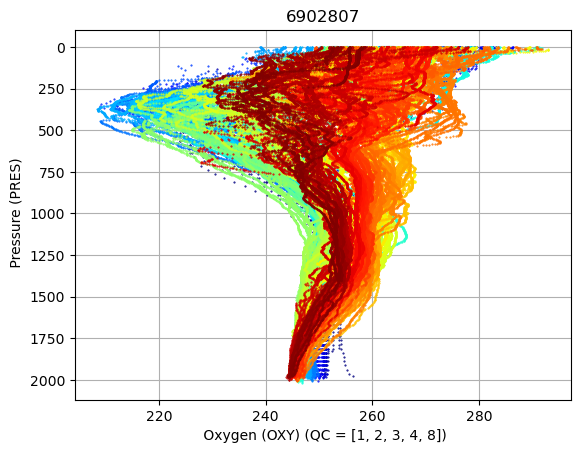

In [11]:
fig.savefig(os.path.join(rep_fic_fig,num_float +'_doxy_cycle_2.png'))
display(fig)

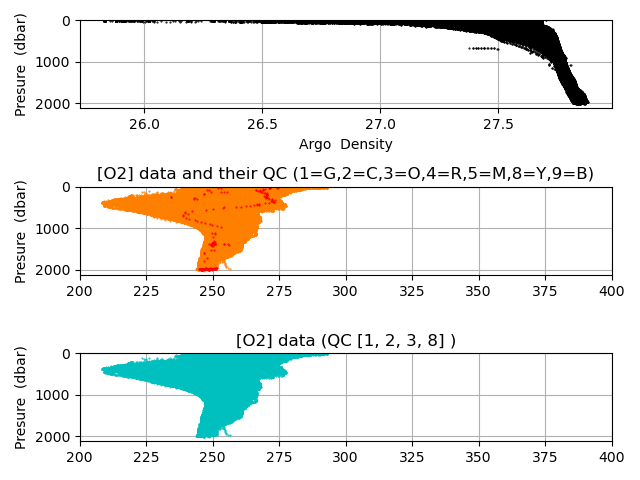

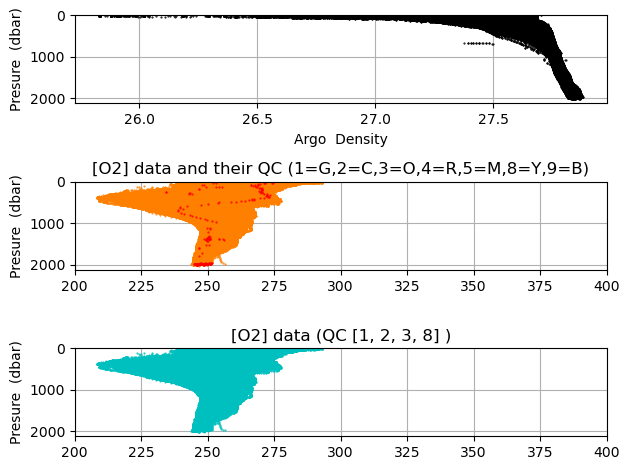

In [12]:
# DOXY_QC plot with PRES/PSAL/TEMP
if info_plot==1:
    fig=plot_DOXY_QC(ds_argo_Sprof,doxy_qc)
    plt.show()
    plt.savefig(os.path.join(rep_fic_fig,num_float +'_doxy_qc.png'))
    display(fig)

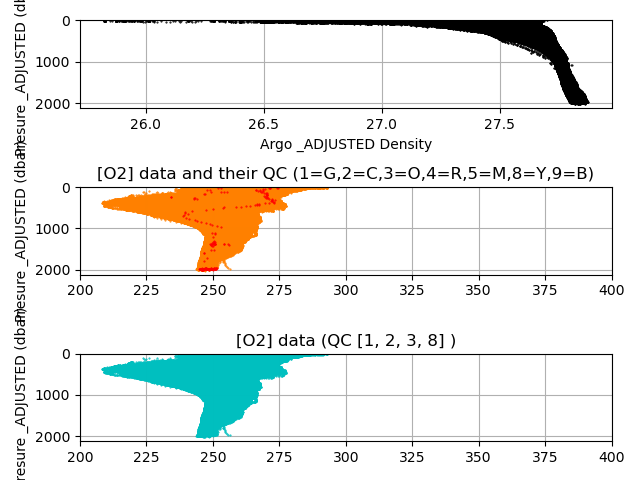

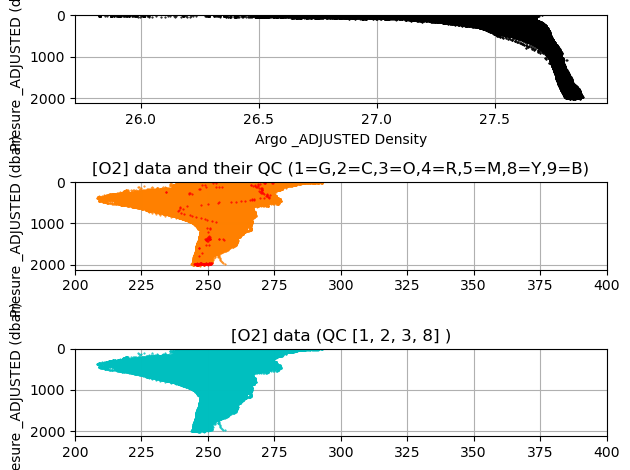

In [13]:
# Same with DATA ADJUSTED (PRES,PSAL,TEMP)
if info_plot==1:
    fig = plot_DOXY_QC(ds_argo_Sprof,doxy_qc,'_ADJUSTED')
    plt.show()
    fig.savefig(os.path.join(rep_fic_fig,num_float +'_doxy_qc_PTS_adjusted.png'))
    display(fig)

PRES
TEMP
PSAL


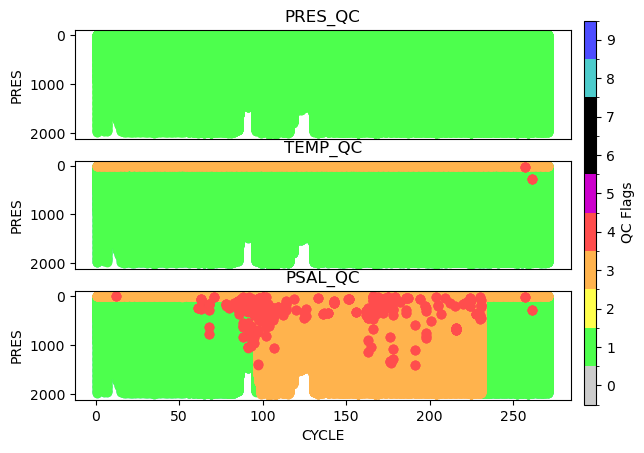

In [14]:
# PRES/PSAL/TEMP QC
if info_plot==1:
    fig=plot_QC_cycle(ds_argo_Sprof)
    fig.savefig(os.path.join(rep_fic_fig,num_float +'_PTS_QC.png'))
    display(fig)

PRES_ADJUSTED
TEMP_ADJUSTED
PSAL_ADJUSTED


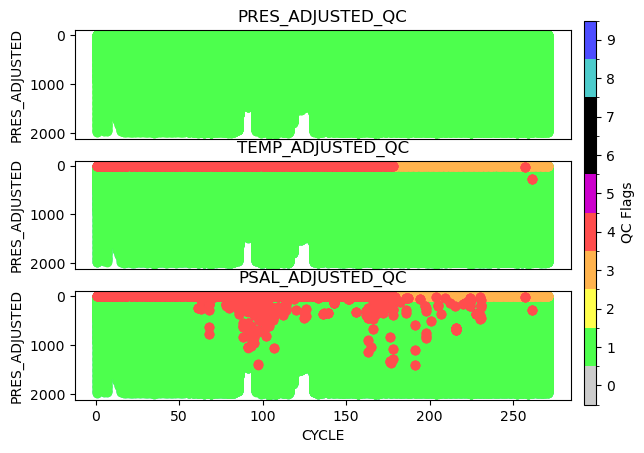

In [15]:
# Same with adjusted DATA
if info_plot==1:
    fig=plot_QC_cycle(ds_argo_Sprof,'_ADJUSTED')
    fig.savefig(os.path.join(rep_fic_fig,num_float +'_PTS_Adjusted_QC.png'))
    display(fig)

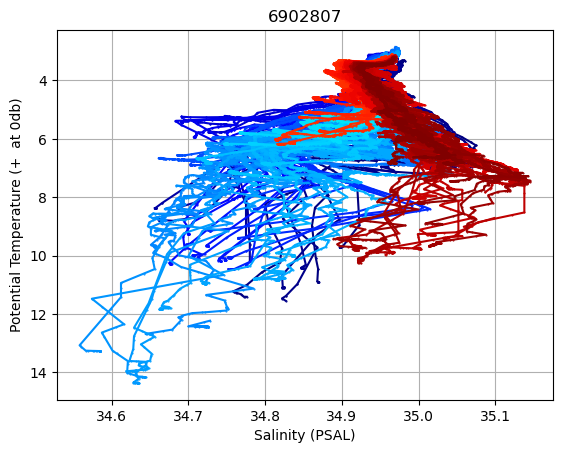

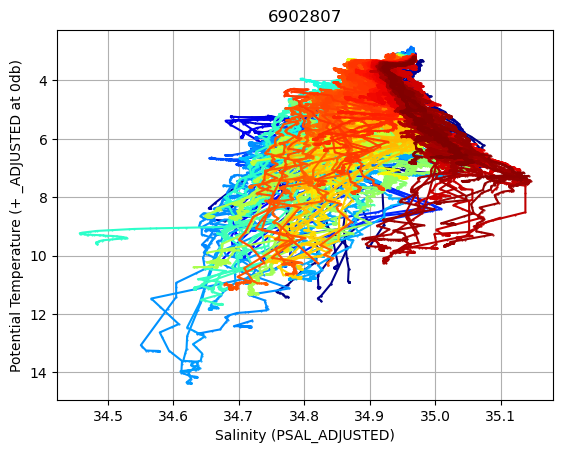

In [16]:
# Theta/S
#_=plot_Theta_S(ds_argo_Sprof)
#_=plot_Theta_S(ds_argo_Sprof,'_ADJUSTED')
fig=plot_Theta_S(ds_argo_Sprof,qc_keep=[1,2,8])
fig.savefig(os.path.join(rep_fic_fig,num_float +'_theta_S.png'))
display(fig)
fig=plot_Theta_S(ds_argo_Sprof,'_ADJUSTED',qc_keep=[1,2,8])
fig.savefig(os.path.join(rep_fic_fig,num_float +'_theta_S_adjusted.png'))
display(fig)

# Get WOA and NCEP DATA
- Attention : The WOA file is a LOPS home-made file

In [17]:
# WOA file reading
maison = 1
if maison==0:
    download_NCEP_if_needed(ds_argo_Sprof['JULD'],ftp_server,rep_ftp,rep_NCEP_data,ncep_variables)

We look for PSAL in Sprof near the surface between 0 and 10
We look for PSAL_ADJUSTED in Sprof near the surface between 0 and 10


/Users/chemon/miniforge3/envs/pydox_conda_forge/lib/python3.10/site-packages/xarray/structure/concat.py:547: UserWarning: No index created for dimension CYCLE_NUMBER because variable CYCLE_NUMBER is not a coordinate. To create an index for CYCLE_NUMBER, please first call `.set_coords('CYCLE_NUMBER')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/Users/chemon/miniforge3/envs/pydox_conda_forge/lib/python3.10/site-packages/xarray/structure/concat.py:547: UserWarning: No index created for dimension CYCLE_NUMBER because variable CYCLE_NUMBER is not a coordinate. To create an index for CYCLE_NUMBER, please first call `.set_coords('CYCLE_NUMBER')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


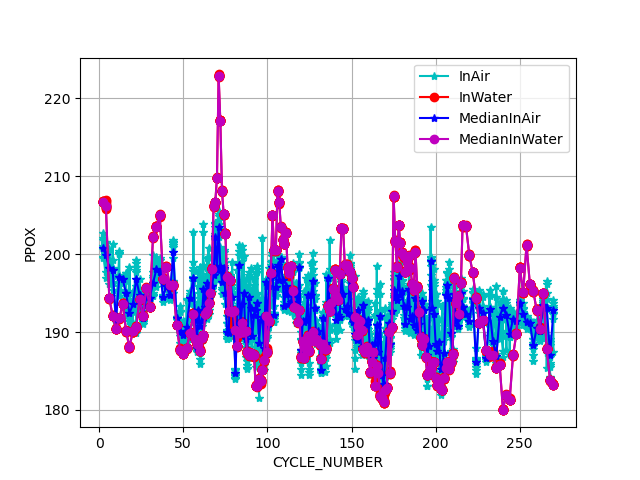

PSAL_ADJUSTED is used if exists, otherwise PSAL.

Cycle 149.0
Rtraj Temperature  differs more than  0.5 degrees from Sprof Temperature
Cycle 178.0
Rtraj Temperature  differs more than  0.5 degrees from Sprof Temperature
Cycle 264.0
Rtraj Temperature  differs more than  0.5 degrees from Sprof Temperature


In [18]:
dsair_tot,dsinwater_tot = get_argo_data_for_NCEP(ds_argo_Rtraj,ds_argo_Sprof,which_var,code_inair,code_inwater,min_pres,max_pres)

In [19]:
f = open(fic_res_ASCII,'w')
nb_value = []
gain_error = []
gain_carryover_error = []
carryover_error = []
gain_drift_gain_error = []
gain_drift_drift_error =[]
gain_drift_carryover_gain_error =[]
gain_drift_carryover_drift_error =[]
gain_drift_carryover_carryover_error =[]
BIC_Gain = []
BIC_Gain_CarryOver = []
BIC_Gain_Drift = []
BIC_Gain_Drift_CarryOver = []

for nb_cycle in range(10, int(ds_argo_Sprof['CYCLE_NUMBER'][-1])+1, 10):
    #print(nb_cycle)
    dsair = dsair_tot.copy()
    dsinwater = dsinwater_tot.copy()
    dsair = dsair.where((dsair['CYCLE_NUMBER']>=first_cycle_to_use) & (dsair['CYCLE_NUMBER']<=nb_cycle),drop=True)
    dsinwater = dsinwater.where((dsinwater['CYCLE_NUMBER']>=first_cycle_to_use) & (dsinwater['CYCLE_NUMBER']<=nb_cycle),drop=True)

    nb_value.append(dsair['CYCLE_NUMBER'].size)
    
    f.write(f"\nfirst_cycle/last_cycle : {dsair['CYCLE_NUMBER'][0].values}/{dsair['CYCLE_NUMBER'][-1].values} Nb_NCEP_data : {dsair['CYCLE_NUMBER'].size}\n")

    PPOX1 = dsair['PPOX_DOXY'].values
    PPOX2 = dsinwater['PPOX_DOXY'].values


    ds_NCEP_air,ds_NCEP_rhum, ds_NCEP_slp = open_NCEP_file(rep_NCEP_data)
    ds_NCEP_air,ds_NCEP_rhum,ds_NCEP_slp = interp_NCEP_on_ARGO(ds_NCEP_air,ds_NCEP_rhum,ds_NCEP_slp,dsair['LONGITUDE_ARGO'],dsair['LATITUDE_ARGO'],dsair['JULD'])
    z0q = 1e-4
    NCEP_PPOX = calcul_NCEP_PPOX(dsinwater,ds_NCEP_air,ds_NCEP_rhum,ds_NCEP_slp,optode_height,z0q)

    delta_T_NCEP = diff_time_in_days(dsair['JULD'].values,launch_date)

# Estimate Gain correction with NCEP 
# without CarryOver
    initial_guess = 1
# Gain
    params_Gain_NCEP, covariance,info,mesg,ier = curve_fit(model_Gain, PPOX1/PPOX1, NCEP_PPOX/PPOX1, p0=initial_guess,nan_policy='omit',full_output=True)
    perr_Gain_NCEP = np.sqrt(np.diag(covariance))
    f.write(f"NCEP Gain estimated : {params_Gain_NCEP} with an error {perr_Gain_NCEP}\n")
    gain_error.append(perr_Gain_NCEP)
    
    residuals = NCEP_PPOX/PPOX1 - model_Gain(PPOX1/PPOX1, *params_Gain_NCEP)
    SSR = np.nansum(residuals**2)
    n = len(PPOX1)  # nombre d'observations
    k = len(params_Gain_NCEP)  # nombre de paramètres estimés
    BIC_Gain.append(np.log(SSR/n) + k * np.log(n)/n)
    f.write(f"Gain estimated BIC : {np.log(SSR/n) + k * np.log(n)/n}\n")

    #BIC_Gain.append(n*np.log(SSR/n) + k * np.log(n))


# with CarryOver
    initial_guess = [1, 0]  # Valeurs initiales pour G et C
    params_Gain_NCEP_CarryOver, covariance = curve_fit(model_Gain_CarryOver, [PPOX1,PPOX2], NCEP_PPOX, p0=initial_guess,nan_policy='omit')
    perr_Gain_NCEP_CarryOver = np.sqrt(np.diag(covariance))
    f.write(f"NCEP Gain/CarryOver estimated : {params_Gain_NCEP_CarryOver} with an error {perr_Gain_NCEP_CarryOver}\n")
    gain_carryover_error.append(perr_Gain_NCEP_CarryOver[0])
    carryover_error.append(perr_Gain_NCEP_CarryOver[1])

    residuals = NCEP_PPOX - model_Gain_CarryOver([PPOX1,PPOX2], *params_Gain_NCEP_CarryOver)
    SSR = np.nansum(residuals**2)
    n = len(PPOX1)  # nombre d'observations
    k = len(params_Gain_NCEP_CarryOver)  # nombre de paramètres estimés
    BIC_Gain_CarryOver.append(np.log(SSR/n) + k * np.log(n)/n)
    f.write(f"Gain/CarryOver estimated BIC : {np.log(SSR/n) + k * np.log(n)/n}\n")

    #BIC_Gain_CarryOver.append(n*np.log(SSR/n) + k * np.log(n))
    

# Estimate Gain/Drift correction with NCEP 
# without CarryOver
    initial_guess = [1, 0]  # G/D
    params_Gain_Derive_NCEP, covariance,info,mesg,ier = curve_fit(model_Gain_Derive, [PPOX1/PPOX1,delta_T_NCEP], NCEP_PPOX/PPOX1, p0=initial_guess,nan_policy='omit',full_output=True)
    perr_Gain_Derive_NCEP = np.sqrt(np.diag(covariance))
    f.write(f"Gain/Drift estimated : {params_Gain_Derive_NCEP} with an error {perr_Gain_Derive_NCEP}\n")
    gain_drift_gain_error.append(perr_Gain_Derive_NCEP[0])
    gain_drift_drift_error.append(perr_Gain_Derive_NCEP[1])

    residuals = NCEP_PPOX/PPOX1- model_Gain_Derive([PPOX1/PPOX1,delta_T_NCEP], *params_Gain_Derive_NCEP)
    SSR = np.nansum(residuals**2)
    n = len(PPOX1)  # nombre d'observations
    k = len(params_Gain_Derive_NCEP)  # nombre de paramètres estimés
    BIC_Gain_Drift.append(np.log(SSR/n) + k * np.log(n)/n)
    f.write(f"Gain/Drift estimated BIC : {np.log(SSR/n) + k * np.log(n)/n}\n")

    #BIC_Gain_Drift.append(n*np.log(SSR/n) + k * np.log(n))

# with CarryOver
    initial_guess = [1, 0, 0]  # G/C/D
    params_Gain_Derive_NCEP_CarryOver, covariance = curve_fit(model_Gain_Derive_CarryOver, [PPOX1,PPOX2,delta_T_NCEP], NCEP_PPOX, p0=initial_guess,nan_policy='omit')
    perr_Gain_Derive_NCEP_CarryOver = np.sqrt(np.diag(covariance))
    f.write(f"Gain/CarryOver/Drift estimated : {params_Gain_Derive_NCEP_CarryOver} with an error {perr_Gain_Derive_NCEP_CarryOver}\n")
    gain_drift_carryover_gain_error.append(perr_Gain_Derive_NCEP_CarryOver[0])
    gain_drift_carryover_carryover_error.append(perr_Gain_Derive_NCEP_CarryOver[1])
    gain_drift_carryover_drift_error.append(perr_Gain_Derive_NCEP_CarryOver[2])

    residuals = NCEP_PPOX - model_Gain_Derive_CarryOver([PPOX1,PPOX2,delta_T_NCEP], *params_Gain_Derive_NCEP_CarryOver)
    SSR = np.nansum(residuals**2)
    n = len(PPOX1)  # nombre d'observations
    k = len(params_Gain_Derive_NCEP_CarryOver)  # nombre de paramètres estimés
    BIC_Gain_Drift_CarryOver.append(np.log(SSR/n) + k * np.log(n)/n)
    f.write(f"Gain/CarryOver/Drift estimated BIC : {np.log(SSR/n) + k * np.log(n)/n}\n")

    #BIC_Gain_Drift_CarryOver.append(n*np.log(SSR/n) + k * np.log(n))

f.close()

In [20]:
if plt.get_fignums():  # Si des figures sont ouvertes
    plt.close('all') 
    

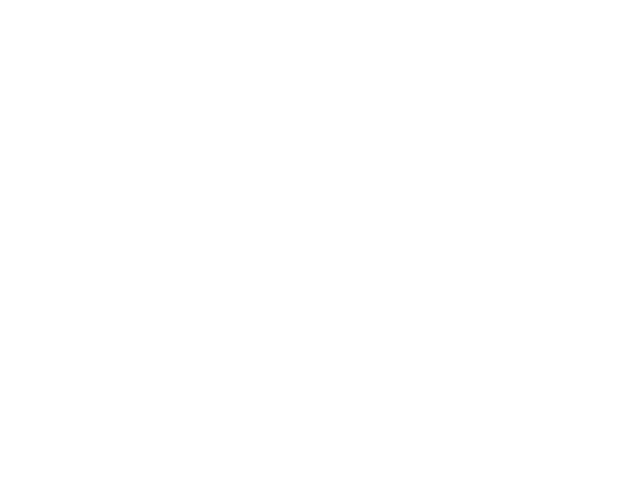

In [21]:
fig, ax = plt.subplots(3,3)
_=ax[0,0].plot(nb_value,gain_error,'.b-')
ax[0,0].set_ylabel('Gain Error')
ax[0,0].grid()
ax[0,0].set_title('Gain (sans/avec CarryOver)', fontsize=12, loc='center', pad=20)
_=ax[0,1].plot(nb_value,gain_carryover_error,'.b-')
ax[0,1].set_ylabel('Gain Error')
ax[0,1].grid()
_=ax[0,2].plot(nb_value,carryover_error,'.b-')
ax[0,2].set_ylabel('CarryOver Error')
ax[0,2].grid()

_=ax[1,0].plot(nb_value,gain_drift_gain_error,'.b-')
ax[1,0].set_ylabel('Gain Error')
ax[1,0].grid()
ax[1,0].set_title('Gain/Derive', fontsize=12, loc='center', pad=20)
_=ax[1,1].plot(nb_value,gain_drift_drift_error,'.b-')
ax[1,1].set_ylabel('Drift Error')
ax[1,1].grid()

_=ax[2,0].plot(nb_value,gain_drift_carryover_gain_error,'.b-')
ax[2,0].set_ylabel('Gain Error')
ax[2,0].grid()
ax[2,0].set_title('Gain/Derive CarryOver', fontsize=12, loc='center', pad=20)
_=ax[2,1].plot(nb_value,gain_drift_carryover_drift_error,'.b-')
ax[2,1].set_ylabel('Drift Error')
ax[2,1].grid()
_=ax[2,2].plot(nb_value,gain_drift_carryover_carryover_error,'.b-')
ax[2,2].set_ylabel('CarryOver Error')
ax[2,2].grid()
plt.tight_layout()

plt.show()

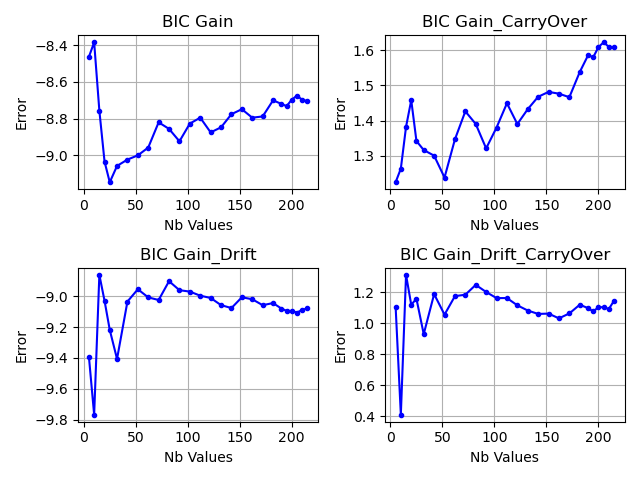

In [22]:
fig, ax = plt.subplots(2,2)
_=ax[0,0].plot(nb_value,BIC_Gain,'.b-')
ax[0,0].set_ylabel('Error')
ax[0,0].set_xlabel('Nb Values')
ax[0,0].grid()
ax[0,0].set_title('BIC Gain')

_=ax[0,1].plot(nb_value,BIC_Gain_CarryOver,'.b-')
ax[0,1].set_ylabel('Error')
ax[0,1].set_xlabel('Nb Values')
ax[0,1].grid()
ax[0,1].set_title('BIC Gain_CarryOver')

_=ax[1,0].plot(nb_value,BIC_Gain_Drift,'.b-')
ax[1,0].set_ylabel('Error')
ax[1,0].set_xlabel('Nb Values')
ax[1,0].grid()
ax[1,0].set_title('BIC Gain_Drift')

_=ax[1,1].plot(nb_value,BIC_Gain_Drift_CarryOver,'.b-')
ax[1,1].set_ylabel('Error')
ax[1,1].set_xlabel('Nb Values')
ax[1,1].grid()
ax[1,1].set_title('BIC Gain_Drift_CarryOver')

plt.tight_layout()

plt.show()

In [23]:
residuals = NCEP_PPOX/PPOX1 - model_Gain(PPOX1/PPOX1, *params_Gain_NCEP)
SSR = np.nansum(residuals**2)
n = len(PPOX1)  # nombre d'observations
k = len(params_Gain_NCEP)  # nombre de paramètres estimés
(np.log(SSR/n) + k * np.log(n)/n)

np.float64(-8.705239831206109)

In [24]:
np.log(SSR/n)

np.float64(-8.730219542964843)